# Exercise 6 preprocessing

Same idea as exercise 4/5: load the NASA exoplanet data, remove rows with missing values, then log-transform the physical variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


data_file = "PS_2026.05.15_08.06.21.csv"
planets = pd.read_csv(data_file, comment="#")

planets.head()

,loc_rowid,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,1,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
1,2,11 Com b,11 Com,1,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-12,2023-09-19
2,3,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
4,5,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14


In [2]:
# Feature columns:
# pl_rade    = planet radius [Earth radii]
# pl_masse   = planet mass [Earth masses]
# pl_dens    = planet density [g/cm^3]
# pl_orbsmax = orbital distance / semi-major axis [au]

feature_columns = ["pl_rade", "pl_masse", "pl_dens", "pl_orbsmax"]

sample_a = planets[feature_columns].apply(pd.to_numeric, errors="coerce")
sample_a = sample_a.dropna()
sample_a = sample_a[(sample_a > 0).all(axis=1)]
sample_a = sample_a.to_numpy()

print("number of planets in sample_a:", len(sample_a))

number of planets in sample_a: 2121


In [3]:
# sample_a[:,0] = planet radius
# sample_a[:,1] = planet mass
# sample_a[:,2] = planet density
# sample_a[:,3] = orbital distance

planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
planet_density = sample_a[:, 2].copy()
orbital_distance = sample_a[:, 3].copy()

# log10 transformation, same idea as sheet 5
log_planet_r = np.log10(planet_r)
log_planet_m = np.log10(planet_m)
log_planet_density = np.log10(planet_density)
log_orbital_distance = np.log10(orbital_distance)

log_sample_a = np.column_stack((
    log_planet_r,
    log_planet_m,
    log_planet_density,
    log_orbital_distance
))

# Final D-dimensional feature space: D = 4
X = log_sample_a.copy()

print("feature-space dimension D:", X.shape[1])

feature-space dimension D: 4


## Transformation choice

I use a logarithmic transformation for radius, mass, density, and orbital distance because these quantities are positive and span very large ranges. The log transform compresses the scale, reduces skewness, and stops very large planets or very wide orbits from dominating the feature space.

Density is useful because it contains information about composition, but it is correlated with mass and radius.

## Gaussian mixture models

Start by fitting two Gaussian components to each 2D combination of the four log-transformed variables.

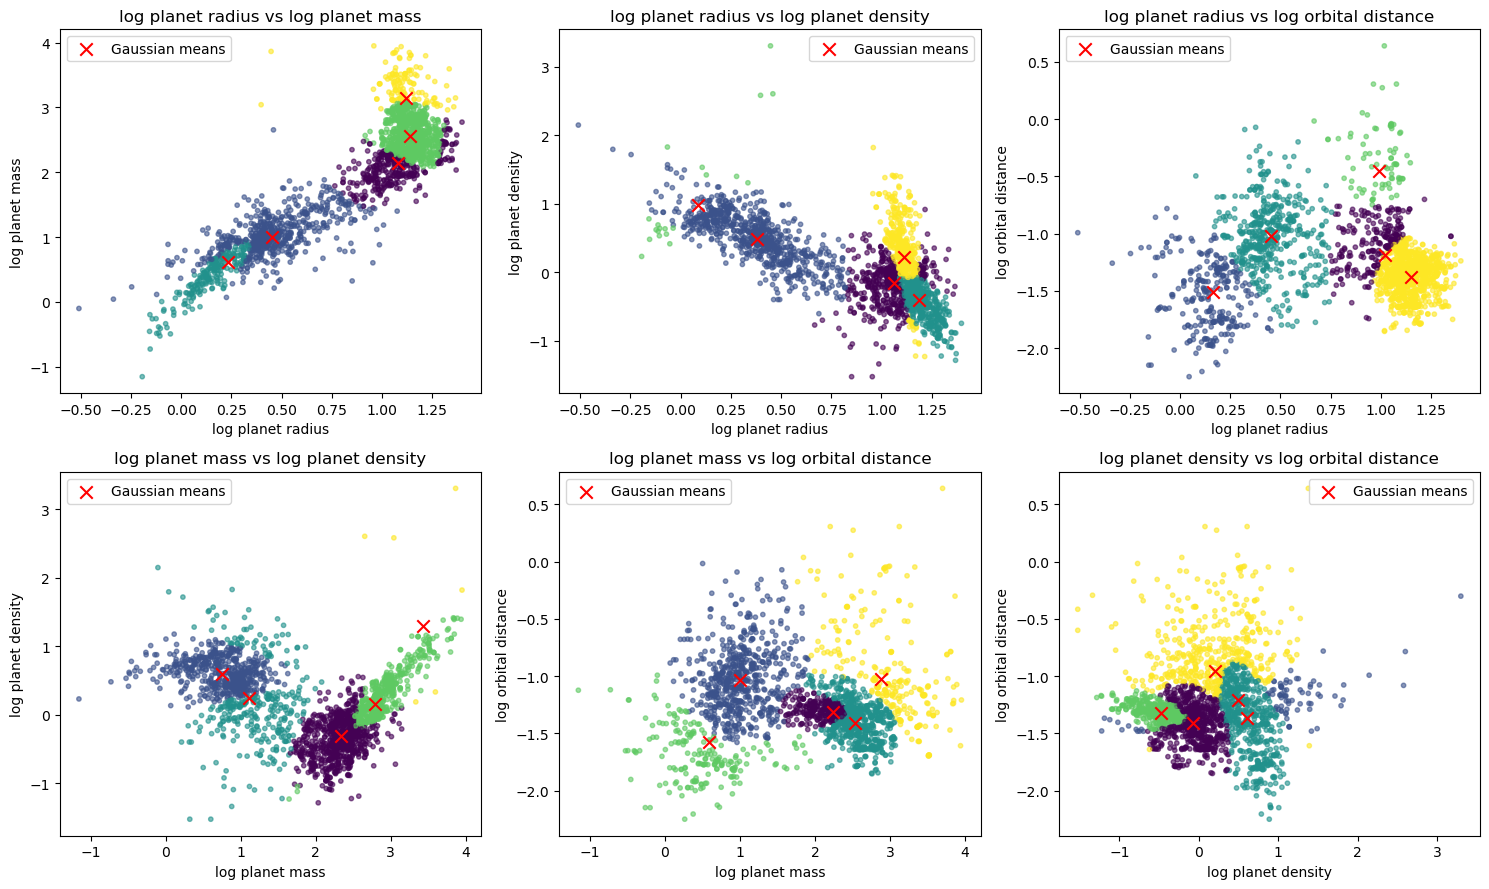

In [4]:
from itertools import combinations
from sklearn.mixture import GaussianMixture


feature_names = [
    "log planet radius",
    "log planet mass",
    "log planet density",
    "log orbital distance"
]

n_components = 5

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.ravel()

for ax, (i, j) in zip(axs, combinations(range(4), 2)):
    X_pair = log_sample_a[:, [i, j]]

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    labels = gmm.fit_predict(X_pair)

    ax.scatter(
        X_pair[:, 0],
        X_pair[:, 1],
        c=labels,
        s=10,
        alpha=0.6
    )

    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        c="red",
        marker="x",
        s=80,
        label="Gaussian means"
    )

    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:


feature_spaces = {
    "2D radius-mass": [0, 1],
    "2D radius-density": [0, 2],
    "2D radius-orbit": [0, 3],
    "2D mass-orbit": [2, 3],
    "3D radius-mass-orbit": [0, 1, 3],
    "3D radius-density-orbit": [0, 2, 3],
    "4D all": [0, 1, 2, 3],
}

results = []

for name, cols in feature_spaces.items():
    X_use = log_sample_a[:, cols]

    for k in range(1, 9):
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X_use)

        results.append([name, k, gmm.bic(X_use)])

bic_results = pd.DataFrame(results, columns=["feature_space", "k", "BIC"])



In [6]:
best_bic = bic_results.loc[
    bic_results.groupby("feature_space")["BIC"].idxmin()
]

best_bic


,feature_space,k,BIC
31,2D mass-orbit,8,3933.533477
12,2D radius-density,5,1547.988116
7,2D radius-mass,8,1538.924595
23,2D radius-orbit,8,385.514608
47,3D radius-density-orbit,8,1426.644906
38,3D radius-mass-orbit,7,1363.536812
54,4D all,7,-10641.781125


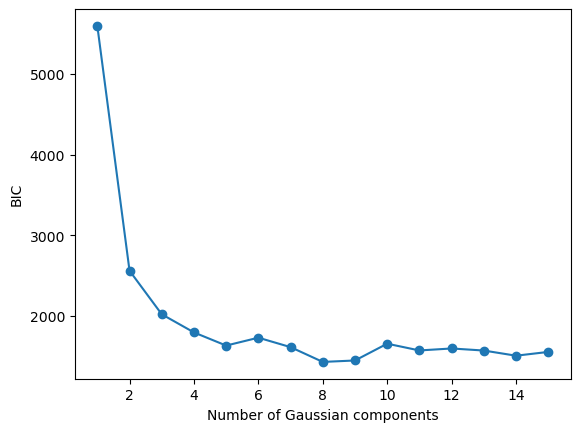

In [7]:
X_3 = log_sample_a[:, [0, 2, 3]]

bic_values = []

for k in range(1, 16):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_3)
    bic_values.append(gmm.bic(X_3))

plt.plot(range(1, 16), bic_values, marker="o")
plt.xlabel("Number of Gaussian components")
plt.ylabel("BIC")
plt.show()


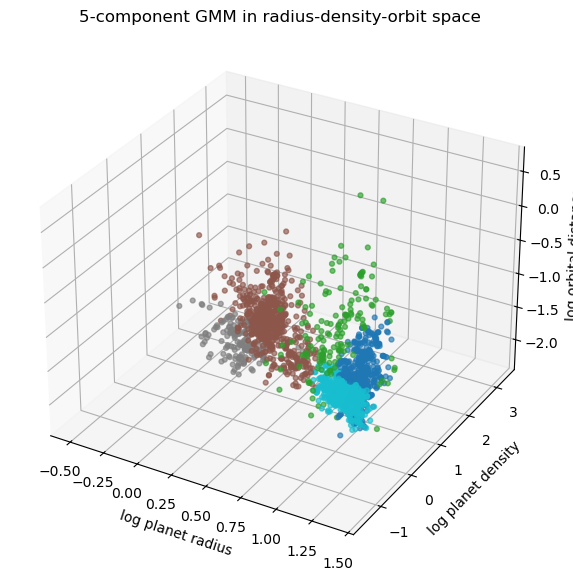

In [8]:

gmm_final = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42,
    n_init=10
)

labels = gmm_final.fit_predict(X_3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_3[:, 0],
    X_3[:, 1],
    X_3[:, 2],
    c=labels,
    s=12,
    alpha=0.65,
    cmap="tab10"
)

ax.set_xlabel("log planet radius")
ax.set_ylabel("log planet density")
ax.set_zlabel("log orbital distance")
ax.set_title("5-component GMM in radius-density-orbit space")

plt.show()


In [9]:
centers = pd.DataFrame(
    gmm_final.means_,
    columns=["log radius", "log density", "log orbital distance"]
)


centers_physical = 10**centers
centers_physical.columns = [
    "radius [Earth radii]",
    "density [g/cm^3]",
    "orbital distance [au]"
]

centers_physical


,radius [Earth radii],density [g/cm^3],orbital distance [au]
0,13.479187,1.397814,0.043226
1,10.229568,1.186676,0.144534
2,2.776028,2.582443,0.084182
3,1.361508,5.858651,0.021792
4,14.038579,0.419863,0.044354


In [10]:
log_labeled_data = pd.DataFrame(
    log_sample_a,
    columns=[
        "log_radius",
        "log_mass",
        "log_density",
        "log_orbital_distance"
    ]
)

log_labeled_data["gmm_label"] = labels

log_labeled_data.head()

,log_radius,log_mass,log_density,log_orbital_distance,gmm_label
0,0.273001,0.902547,0.823474,-1.811353,3
1,0.301030,0.936011,0.770852,-1.800519,3
2,0.283301,0.907411,0.799341,-1.811353,3
3,0.318063,0.892651,0.679428,-1.811353,3
4,0.281033,0.907411,0.806180,-1.811353,3


In [11]:
test_split = log_labeled_data.sample(frac=0.01, random_state=42)
train_split = log_labeled_data.drop(test_split.index)


## Classification of test data

In [12]:
X_train = train_split.to_numpy()
X_test = test_split.to_numpy()

y_train = X_train[:,-1]
X_train = X_train[:,0:-1]

y_test = X_test[:,-1]
X_test = X_test[:,0:-1]


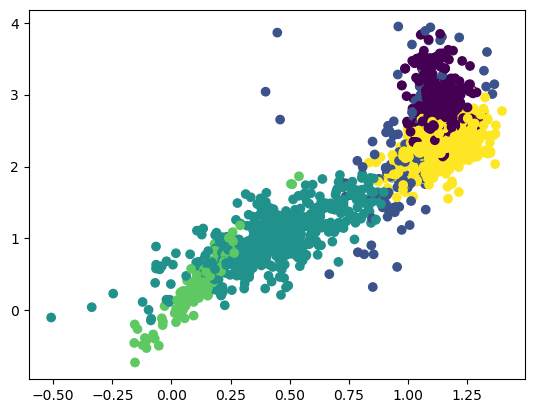

In [13]:
plt.scatter(X_train[:,0],X_train[:,1], c=y_train)

In [14]:
solar_planets = np.array([[2439.4, 0.330103e24, 5.4289, 0.2408467, 3],   #mean radius (because I think it says more about mass
                          [6051.8, 4.86731e24, 5.243, 0.61519726, 3],
                          [6371.0084, 5.97217e24, 5.5134, 1.0000174, 3],
                          [3389.50, 0.641691e24, 3.9340, 1.8808476, 3],
                          [69911, 1898.125e24, 1.3262, 11.862615, 1],
                          [58232, 568.317e24, 0.6871, 29.447498, 1],
                          [25362, 86.8099e24, 1.270, 84.016846, 2],
                          [24622, 102.4092e24, 1.638, 164.79132, 2]])


# Feature columns:
#  0: planet radius [Earth radii]
#  1: planet mass [Earth masses]
#  2: planet density [g/cm^3]
#  3: orbital distance / semi-major axis [au]
#  4: class



solar_planets[:,0] = solar_planets[:,0] / 6378 #converting radius km -> earth radius
solar_planets[:,1] = solar_planets[:,1] /5.972e+24
solar_planets[:,2] = solar_planets[:,2]

solarplanet_r = solar_planets[:, 0].copy() #apply logarithmic transformation
solarplanet_m = solar_planets[:, 1].copy()
solarplanet_dens = solar_planets[:, 2].copy()
solarplanet_orbital = solar_planets[:,3].copy()


# log10 transformation
log_solarplanet_r = np.log10(solarplanet_r)
log_solarplanet_m = np.log10(solarplanet_m)
log_solarplanet_dens = np.log10(solarplanet_dens)
log_solarplanet_orbital = np.log10(solarplanet_orbital)

log_solar_planets = np.column_stack((log_solarplanet_r, log_solarplanet_m,
                                     log_solarplanet_dens, log_solarplanet_orbital, solar_planets[:,-1]))

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=1)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn7 = KNeighborsClassifier(n_neighbors=7)

knn1.fit(X_train, y_train)
knn3.fit(X_train, y_train)
knn5.fit(X_train, y_train)
knn7.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


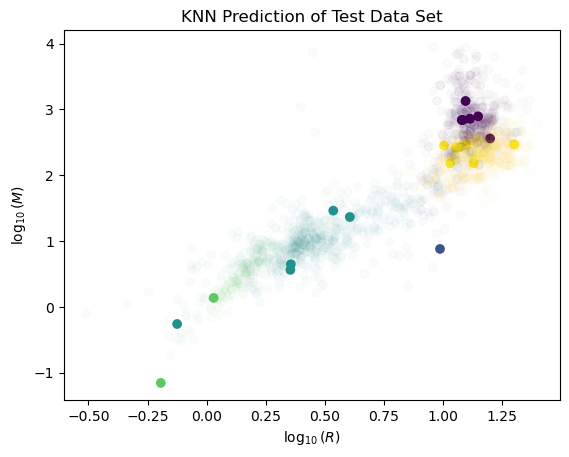

In [16]:
prediction1 = knn1.predict(X_test)
prediction3 = knn3.predict(X_test)
prediction5 = knn5.predict(X_test)
prediction7 = knn7.predict(X_test)

pred_s1 = knn1.predict(log_solar_planets[:,0:-1])
pred_s3 = knn3.predict(log_solar_planets[:,0:-1])
pred_s5 = knn5.predict(log_solar_planets[:,0:-1])
pred_s7 = knn7.predict(log_solar_planets[:,0:-1])


plt.scatter(X_test[:,0], X_test[:,1], c = prediction1)
plt.scatter(X_train[:,0], X_train[:,1], c = y_train, alpha = 0.02)
plt.xlabel('$\log_{10}(R)$')
plt.ylabel('$\log_{10}(M)$')
plt.title("KNN Prediction of Test Data Set")
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score

conf1 = confusion_matrix(y_test, prediction1)
acc1 = accuracy_score(y_test, prediction1)

conf_s1 = confusion_matrix(log_solar_planets[:,-1], pred_s1)
acc_s1 = accuracy_score(log_solar_planets[:,-1], pred_s1)

conf3 = confusion_matrix(y_test, prediction3)
acc3 = accuracy_score(y_test, prediction3)

conf_s3 = confusion_matrix(log_solar_planets[:,-1], pred_s3)
acc_s3 = accuracy_score(log_solar_planets[:,-1], pred_s3)


conf5 = confusion_matrix(y_test, prediction5)
acc5 = accuracy_score(y_test, prediction5)

conf_s5 = confusion_matrix(log_solar_planets[:,-1], pred_s5)
acc_s5 = accuracy_score(log_solar_planets[:,-1], pred_s5)


conf7 = confusion_matrix(y_test, prediction7)
acc7 = accuracy_score(y_test, prediction7)

conf_s7 = confusion_matrix(log_solar_planets[:,-1], pred_s7)
acc_s7 = accuracy_score(log_solar_planets[:,-1], pred_s7)

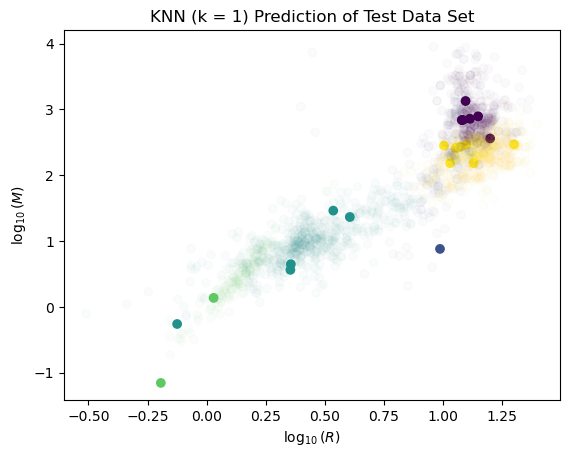

In [18]:
plt.scatter(X_test[:,0], X_test[:,1], c = prediction1)
plt.scatter(X_train[:,0], X_train[:,1], c = y_train, alpha = 0.02)
plt.xlabel('$\log_{10}(R)$')
plt.ylabel('$\log_{10}(M)$')
plt.title("KNN (k = 1) Prediction of Test Data Set")
plt.show()

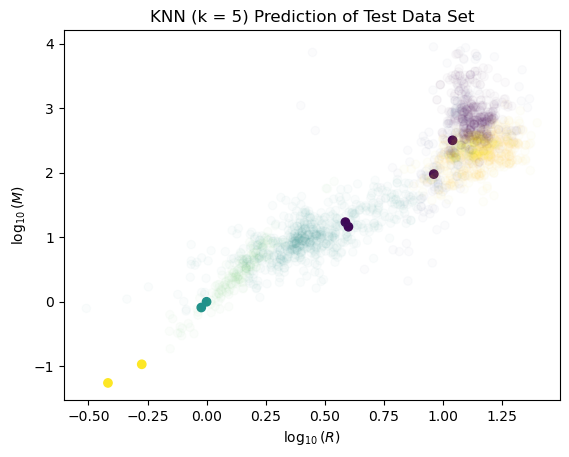

In [31]:
plt.scatter(log_solar_planets[:,0], log_solar_planets[:,1], c = pred_s5)
plt.scatter(X_train[:,0], X_train[:,1], c = y_train, alpha = 0.02)
plt.xlabel('$\log_{10}(R)$')
plt.ylabel('$\log_{10}(M)$')
plt.title("KNN (k = 5) Prediction of Test Data Set")
plt.savefig("figclassification.png")
plt.show()

In [20]:
print("=== Test Set Accuracies ===")
print(f"k=1 : {acc1:.3f}")
print(f"k=3 : {acc3:.3f}")
print(f"k=5 : {acc5:.3f}")
print(f"k=7 : {acc7:.3f}")

print("\n=== Solar System Accuracies ===")
print(f"k=1 : {acc_s1:.3f}")
print(f"k=3 : {acc_s3:.3f}")
print(f"k=5 : {acc_s5:.3f}")
print(f"k=7 : {acc_s7:.3f}")

=== Test Set Accuracies ===
k=1 : 0.952
k=3 : 0.952
k=5 : 1.000
k=7 : 1.000

=== Solar System Accuracies ===
k=1 : 0.500
k=3 : 0.500
k=5 : 0.500
k=7 : 0.500


In [21]:
#Cluster	Interpretation:
 # 0 hot-Jupiters
 # 1 gas giants
 # 2 super-earth / sub-neptune
 # 3 rocky exoplanets
 # 4 inflated hot Jupiters
 # 3 rocky

#Merkur	rocky exoplanet 3
#Venus	rocky exoplanet 3
#Erde	rocky exoplanet 3
#Mars	rocky exoplanet 3
#Jupiter	gas giant 1
#Saturn	gas giant 1
#Uranus	sub-Neptune  2
#Neptun	sub-Neptune 2

## SVM

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_solar_test_scaled = scaler.transform(log_solar_planets[:,0:-1])

In [23]:
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
y_pred = svm_classifier.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.95
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92         6
         1.0       1.00      1.00      1.00         1
         2.0       1.00      1.00      1.00         4
         3.0       1.00      1.00      1.00         3
         4.0       1.00      0.86      0.92         7

    accuracy                           0.95        21
   macro avg       0.97      0.97      0.97        21
weighted avg       0.96      0.95      0.95        21



In [25]:
y_pred_solar = svm_classifier.predict(X_solar_test_scaled)
print(f"Accuracy: {accuracy_score(log_solar_planets[:,-1], y_pred_solar):.2f}")
print(classification_report(log_solar_planets[:,-1], y_pred_solar))

Accuracy: 0.25
              precision    recall  f1-score   support

         1.0       0.33      1.00      0.50         2
         2.0       0.00      0.00      0.00         2
         3.0       0.00      0.00      0.00         4

    accuracy                           0.25         8
   macro avg       0.11      0.33      0.17         8
weighted avg       0.08      0.25      0.12         8



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
y_pred_solar

array([1., 2., 2., 1., 1., 1., 1., 1.])

In [27]:
log_solar_planets[:,-1]

array([3., 3., 3., 3., 1., 1., 2., 2.])

In [28]:
X_solar_test_scaled

array([[-3.1928541 , -3.50031467,  1.15171233,  1.88116923],
       [-2.19173508, -2.20369101,  1.12361727,  3.0969763 ],
       [-2.13509923, -2.10511815,  1.16416621,  3.72684017],
       [-2.83043161, -3.18002365,  0.89200644,  4.54582719],
       [ 0.50427586,  0.67110334,  0.01524134,  6.93349704],
       [ 0.30287615,  0.09001218, -0.51500242,  8.11227013],
       [-0.61293919, -0.81537619, -0.01967385,  9.4715006 ],
       [-0.64556593, -0.73574658,  0.18550673, 10.34488428]])

In [29]:
X_test_scaled

array([[ 0.90747265,  0.73380364, -0.76496211, -1.60704225],
       [-0.59820899, -0.5901018 ,  0.30514979,  0.14729331],
       [ 0.53877206,  0.57429055, -0.22869302, -0.54953868],
       [-1.23550427, -1.48125923,  0.22956953, -0.33166277],
       [ 0.575288  ,  0.59107764, -0.21725538, -0.80514775],
       [-0.77554751, -0.48257864,  0.90542204,  1.63373031],
       [ 0.36958639, -1.12785555, -2.69521592,  2.8513017 ],
       [ 1.16607856,  0.63352342, -1.50213383, -0.13011679],
       [-2.45086504, -2.39320349,  1.41229444, -0.3532013 ],
       [ 0.64388613,  1.36488596,  0.86850602,  0.07931377],
       [ 0.69052915,  1.0661059 ,  0.27046315, -0.75854788],
       [ 0.41281154,  0.61493954,  0.16658003, -0.99988021],
       [-2.62561947, -3.38651348,  0.2154641 ,  0.37378833],
       [ 0.7297203 ,  0.31739779, -1.0141083 , -0.28504308],
       [-2.05934299, -1.95343828,  1.21881258, -0.975766  ],
       [ 0.47816782,  0.31842715, -0.52337791,  0.05752384],
       [ 0.61369735,  1.

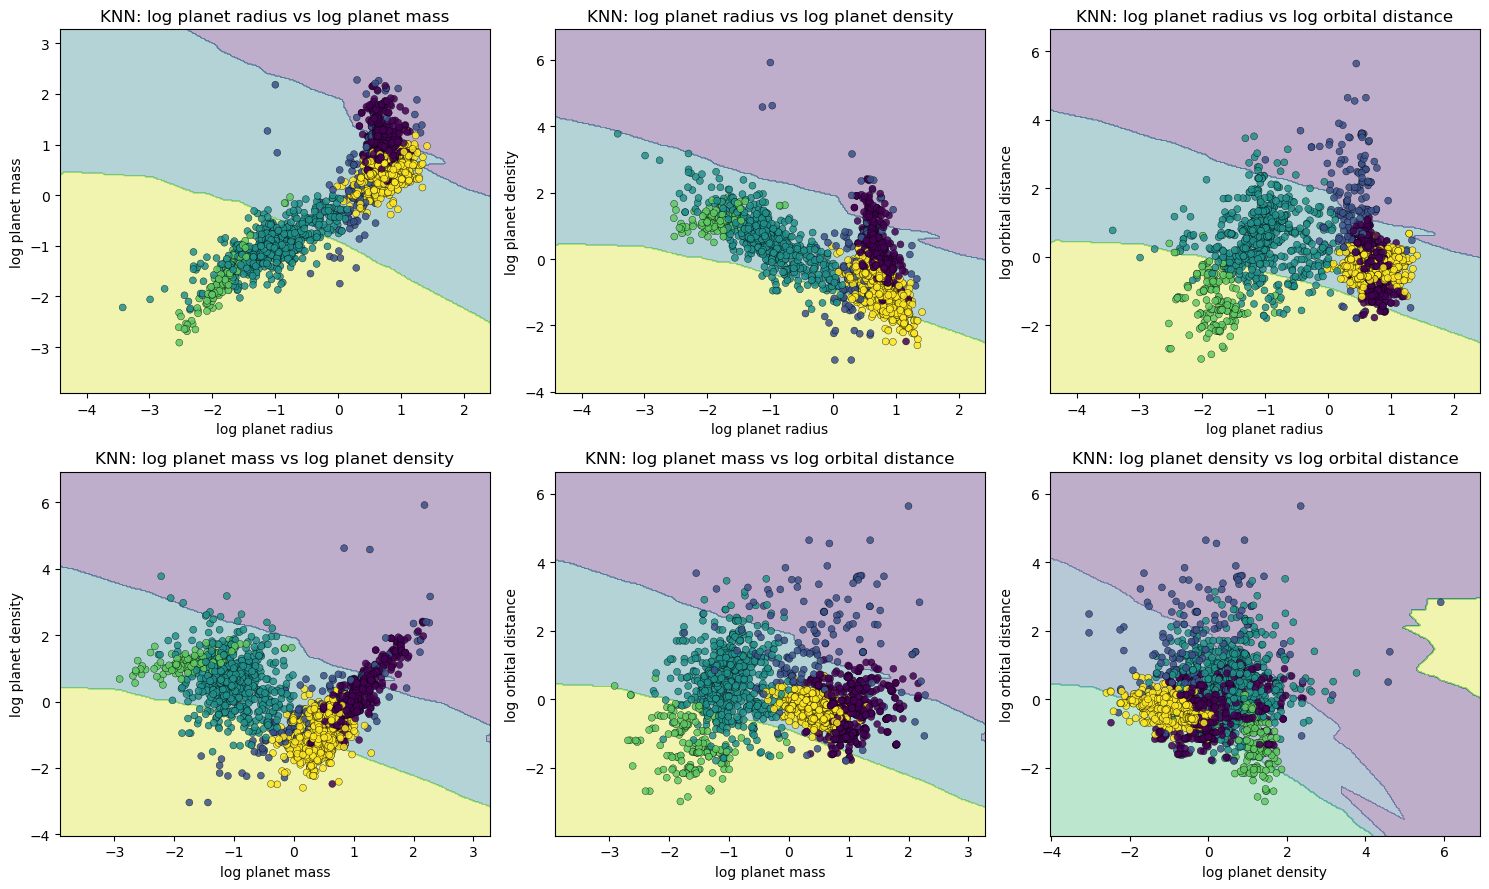

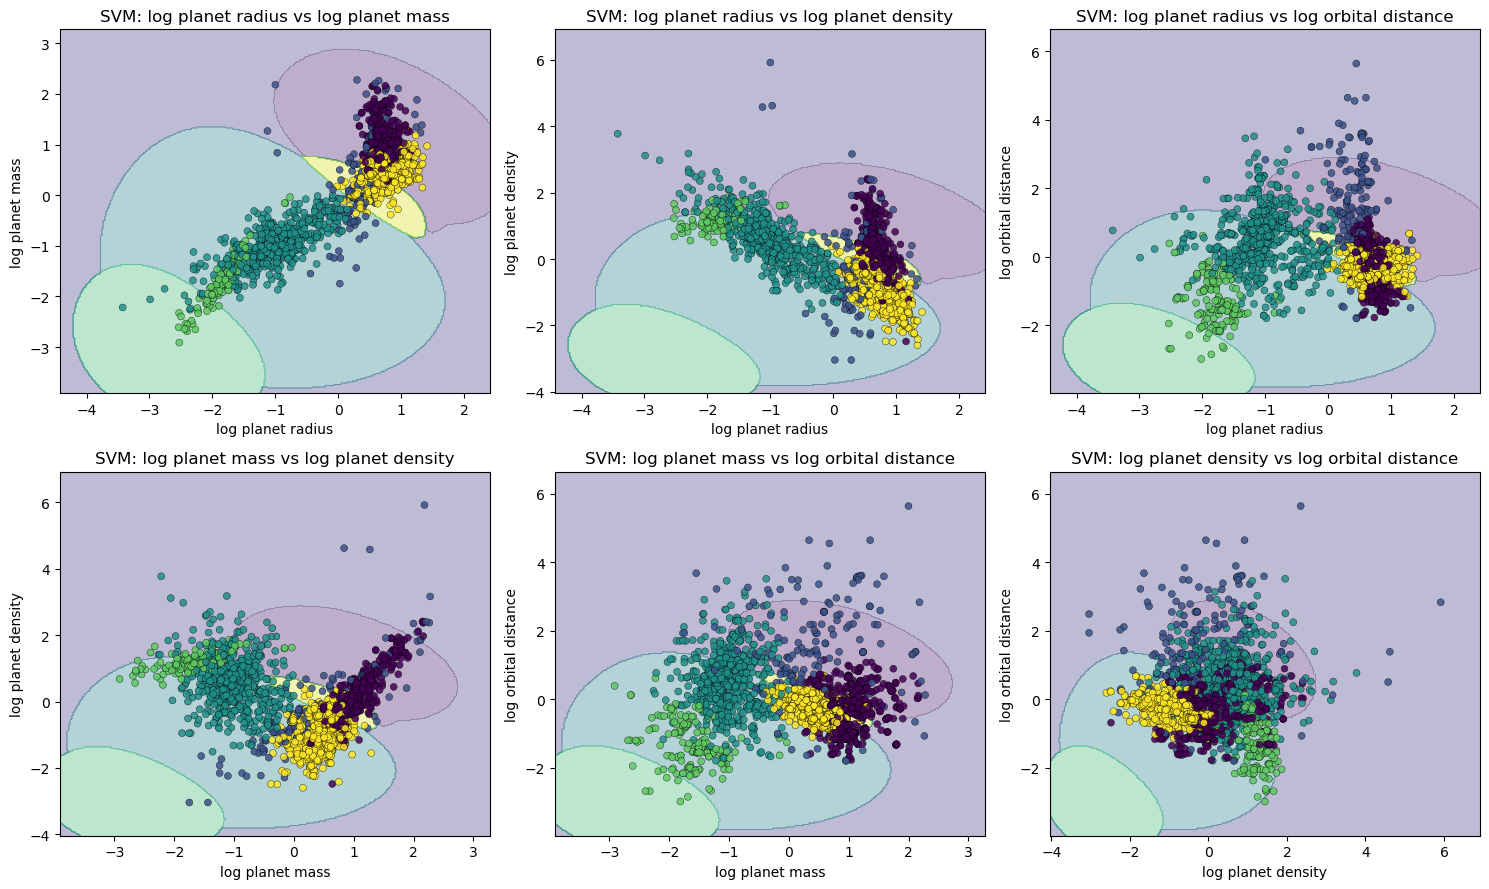

In [37]:
# Improved decision boundary plots with better point separation (subplot version)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

feature_names = [
    "log planet radius",
    "log planet mass",
    "log planet density",
    "log orbital distance"
]

X = X_train_scaled
y = y_train

pairs = list(combinations(range(4), 2))

# --- KNN subplot figure ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.ravel()

for ax, (i, j) in zip(axs, pairs):

    X_pair = X[:, [i, j]]

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    rest_mean = np.mean(np.delete(X, [i, j], axis=1), axis=0)
    grid_rest = np.tile(rest_mean, (xx.ravel().shape[0], 1))

    grid = np.c_[xx.ravel(), yy.ravel(), grid_rest]

    Z_knn = knn5.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z_knn, alpha=0.35)
    ax.scatter(
        X_pair[:, 0], X_pair[:, 1],
        c=y,
        s=25,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.3
    )

    ax.set_title(f"KNN: {feature_names[i]} vs {feature_names[j]}")
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])

plt.tight_layout()
plt.savefig("knn.png")
plt.show()


# --- SVM subplot figure ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.ravel()

for ax, (i, j) in zip(axs, pairs):

    X_pair = X[:, [i, j]]

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    rest_mean = np.mean(np.delete(X, [i, j], axis=1), axis=0)
    grid_rest = np.tile(rest_mean, (xx.ravel().shape[0], 1))

    grid = np.c_[xx.ravel(), yy.ravel(), grid_rest]

    Z_svm = svm_classifier.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z_svm, alpha=0.35)
    ax.scatter(
        X_pair[:, 0], X_pair[:, 1],
        c=y,
        s=25,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.3
    )

    ax.set_title(f"SVM: {feature_names[i]} vs {feature_names[j]}")
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    

plt.tight_layout()
plt.savefig("svm.png")
plt.show()